C:\Users\tracy\AppData\Local\Temp\ipykernel_32268\430580593.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


       Dates  Prices
0 2020-10-31    10.1
1 2020-11-30    10.3
2 2020-12-31    11.0
3 2021-01-31    10.9
4 2021-02-28    10.9
(48, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[ns]
 1   Prices  48 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 900.0 bytes
None


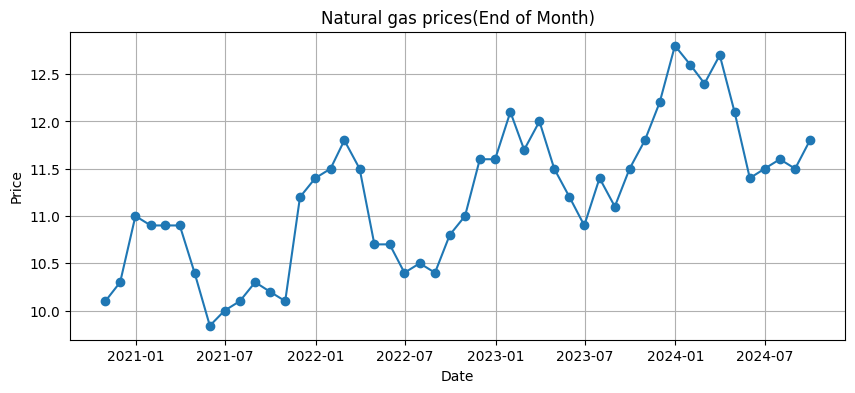

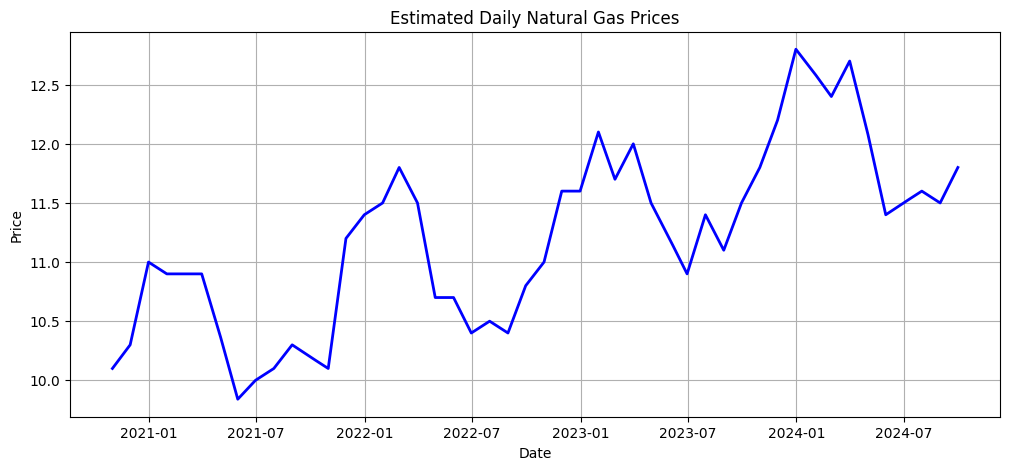

Price on April 15th is 11.1


Enter a date (YYYY-MM-DD):  2022-01-01


Estimated price: 11.403225806451614


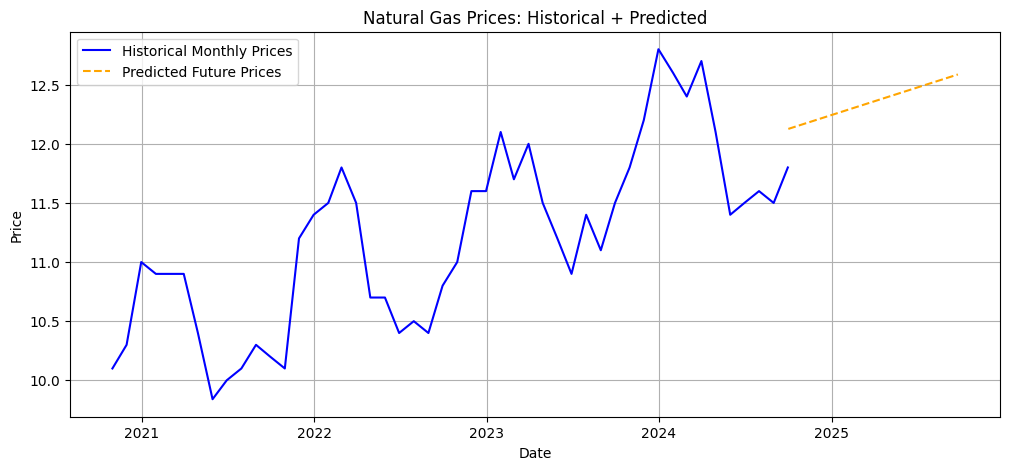

Enter a date (YYYY-MM-DD):  2025-01-02


Predicted price on 2025-01-02: 12.25


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
df = pd.read_csv(r"C:\Users\tracy\Downloads\Nat_Gas.csv")
df['Dates'] = pd.to_datetime(df['Dates'])
df['Prices'] = pd.to_numeric(df['Prices'])
df.head()
print(df.head())
print(df.shape)

df["Dates"] = pd.to_datetime(df["Dates"])
df["Prices"] = pd.to_numeric(df["Prices"], errors='coerce')
print(df.info())
df = df.sort_values('Dates')

plt.figure(figsize=(10, 4))
plt.plot(df['Dates'], df['Prices'], marker='o', linestyle='-')
plt.title("Natural gas prices(End of Month)")
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()     

df =df.set_index('Dates')
df.head()
daily_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_daily = df.reindex(daily_index)
df_daily['Prices'] = df_daily['Prices'].interpolate(method='linear')
df_daily.head(15)

plt.figure(figsize=(12,5))
plt.plot(df_daily.index, df_daily['Prices'], color='blue', linewidth=2)
plt.title("Estimated Daily Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

prices_on_april_15 = df_daily.loc['2022-04-15', 'Prices']
print(f"Price on April 15th is {prices_on_april_15}")
user_input = input("Enter a date (YYYY-MM-DD): ")
try:
    price = df_daily.loc[user_input, 'Prices']
    print(f"Estimated price: {price}")
except KeyError:
    print("Date is out of range or formatted incorrectly")

df.columns
df['DateOrd'] = df.index.map(lambda x: x.toordinal())
x = df['DateOrd'].values.reshape(-1, 1)
y = df['Prices'].values
model = LinearRegression()
model.fit(x, y)

last_date = df.index.max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=360, freq='D')
future_dates_ord = future_dates.map(lambda x: x.toordinal()).values.reshape(-1,1)
future_prices = model.predict(future_dates_ord)
df_future = pd.DataFrame({'Dates': future_dates, 'PredictedPrices': future_prices})

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Prices'], color='blue', label='Historical Monthly Prices')
plt.plot(df_future['Dates'], df_future['PredictedPrices'], color='orange', linestyle='--', label='Predicted Future Prices')
plt.title("Natural Gas Prices: Historical + Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

user_input = input("Enter a date (YYYY-MM-DD): ")
try:
    date_obj = pd.to_datetime(user_input, format='%Y-%m-%d')  
    date_ord = [[date_obj.toordinal()]]
    predicted_price = model.predict(date_ord)[0]
    print(f"Predicted price on {user_input}: {predicted_price:.2f}")
except:
    print("Date is out of range or formatted incorrectly")


In [2]:
import pandas as pd

df = pd.read_csv("C:\\Users\\tracy\\Downloads\\Nat_Gas.csv")
df['Dates'] = pd.to_datetime(df['Dates'])
df['Prices'] = pd.to_numeric(df['Prices'])
df = df.set_index('Dates')
df.head()

def price_storage_contract(df, injection_dates, withdrawal_dates,
                           injection_rate, withdrawal_rate,
                           max_volume, storage_cost):
    current_volume = 0
    total_value = 0

    injection_dates = sorted(injection_dates)
    withdrawal_dates = sorted(withdrawal_dates)

    for date in injection_dates:
        price = df.loc[date, 'Prices'] 
        amount = min(injection_rate, max_volume - current_volume)
        total_value -= amount * price  
        total_value -= storage_cost    
        current_volume += amount

    for date in withdrawal_dates:
        price = df.loc[date, 'Prices'] 
        amount = min(withdrawal_rate, current_volume)
        total_value += amount * price  
        current_volume -= amount
    return total_value
    
injection_dates = [pd.Timestamp('2023-05-31'), pd.Timestamp('2023-06-30')]
withdrawal_dates = [pd.Timestamp('2023-11-30'), pd.Timestamp('2023-12-31')]
contract_value = price_storage_contract(df, injection_dates, withdrawal_dates,
                                        injection_rate=1_000_000, withdrawal_rate=1_000_000,
                                        max_volume=2_000_000, storage_cost=100_000)
print(f"Contract value: ${contract_value:,.2f}")


Contract value: $2,700,000.00


C:\Users\tracy\AppData\Local\Temp\ipykernel_32092\3245182650.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dates'] = pd.to_datetime(df['Dates'])


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df = pd.read_csv(r"C:\Users\tracy\Downloads\Task 3 and 4_Loan_Data.csv")
print(df.head())
print(df['default'].value_counts())

X = df[['credit_lines_outstanding','loan_amt_outstanding','total_debt_outstanding',
        'income','years_employed','fico_score']]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_proba = logreg.predict_proba(X_test_scaled)[:,1]
print("AUC:", roc_auc_score(y_test, y_proba))

def expected_loss(borrower_features: dict, model=logreg, scaler=scaler, recovery_rate=0.1):
    X_new = pd.DataFrame([borrower_features])
    X_new_scaled = scaler.transform(X_new)
    pd_pred = model.predict_proba(X_new_scaled)[:,1][0]
    ead = borrower_features['loan_amt_outstanding']
    exp_loss = pd_pred * ead * (1 - recovery_rate)
    return {"PD": pd_pred, "Expected Loss": exp_loss}

sample = {
    'credit_lines_outstanding': 2,
    'loan_amt_outstanding': 5000,
    'total_debt_outstanding': 12000,
    'income': 40000,
    'years_employed': 3,
    'fico_score': 600
}

print(expected_loss(sample))    

X_scaled_all = scaler.transform(X)
pd_all = logreg.predict_proba(X_scaled_all)[:,1]

recovery_rate = 0.1
ead_all = X['loan_amt_outstanding']
expected_losses = pd_all * ead_all * (1 - recovery_rate)

results = df.copy()
results['PD'] = pd_all
results['Expected_Loss'] = expected_losses

total_expected_loss = results['Expected_Loss'].sum()
print("Total expected loss across portfolio:", total_expected_loss)

print("\nTop 5 borrowers by expected loss:")
print(results[['customer_id','PD','Expected_Loss']].sort_values('Expected_Loss', ascending=False).head())



   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  
default
0    8149
1    1851
Name: count, dtype: int64
AUC: 0.9999896829344681
{'PD': np.float64(0.18896184767828092), 'Expected Loss': 